In [30]:
# Allows you to convert arrays into wav files to play audio
from scipy import signal
from scipy.fft import fftshift
import numpy as np
import matplotlib.pyplot as plt

In [31]:
p_duration = 0.068


samplerate = 44100
t_pulse = np.linspace(0, 1, samplerate)
a = 0.005
q_t = np.array([(1/(((tp-a)**2) + 0.01)) if tp < a else (10/(((tp-a)**2) + 0.1)) for tp in t_pulse])

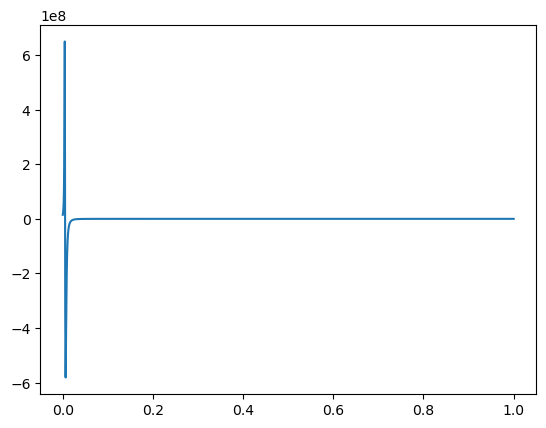

In [32]:
QT = np.array([-2*((tp-a)/((((tp-a)**2)+0.000001))**2) if tp < a else -20*((tp-a)/((((tp-a)**2)+0.000005))**2) for tp in t_pulse])

plt.plot(t_pulse, QT)
plt.show()

In [33]:
# Scale the data to match the 16-bit min/max values of wav file
high = np.iinfo(np.int16).max
pulse_high = np.max(QT)

scale = high/pulse_high
QT_sc = QT[0:500]*scale

In [34]:
# String together a bunch of pulses to make a song
song = np.array([np.concatenate((QT_sc, QT_sc)) for x in range(1, 100)])
song = song.ravel()

t_song = np.arange(0, t_pulse[500]*198, 1/(samplerate))
print(np.size(t_song))
print(np.size(song))

99003
99000


In [35]:
# Create volume envelope for waveform based on sin function
sec_len = round(len(song)/4)
envelope_p1 = np.sin(np.linspace(0, np.pi/2, sec_len*2))
envelope_p2 = np.sin(np.linspace(np.pi/2, np.pi, sec_len*2 + (len(song) - sec_len*4)))
envelope_tot = np.concatenate((envelope_p1, envelope_p2))

In [38]:
# Apply the envelope to the song
final_song = np.array([song[i]*envelope_tot[i] for i in range(0, len(song))])

# Visualize the Spectrogram of the whale song
fs = samplerate
N = len(final_song)
f, t, Sxx = signal.spectrogram(final_song, fs)

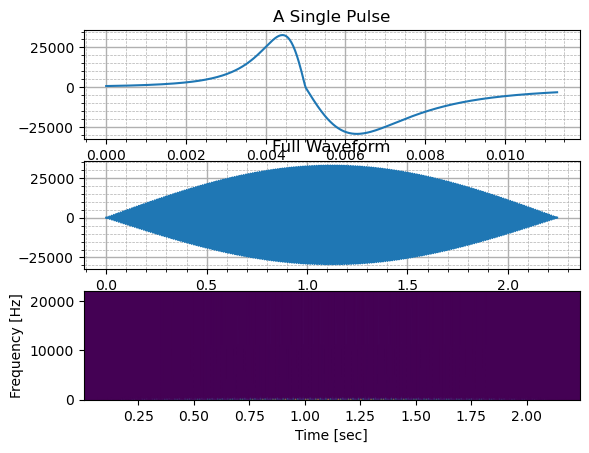

In [39]:
# Visualize the waveforms (a single pulse and a song)
fig, ax = plt.subplots(3)

ax[0].plot(t_pulse[0:500], QT_sc)
ax[0].set_title("A Single Pulse")

ax[1].plot(t_song[0:np.size(song)], final_song)
ax[1].set_title("Full Waveform")

ax[0].minorticks_on()
ax[1].minorticks_on()
ax[0].grid(which='minor', linestyle='--', linewidth=0.5)
ax[0].grid(which='major', linestyle='-', linewidth=1)
ax[1].grid(which='minor', linestyle='--', linewidth=0.5)
ax[1].grid(which='major', linestyle='-', linewidth=1)

ax[2].pcolormesh(t, fftshift(f), fftshift(Sxx, axes=0), shading='gouraud')
ax[2].set_ylabel('Frequency [Hz]')
ax[2].set_xlabel('Time [sec]')

plt.show()